# Joint Diffusion training

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data
from diffusionsim import climsim_utils as cut
from diffusionsim.trainers import AbstractTrainer, DiffusionTrainer

import torch
from typing import Optional
from dataclasses import dataclass, asdict, field
from typing_extensions import Annotated
from pprint import pprint
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [2]:
REF_BATCH_SIZE = 128
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"
climsim_training = True
in_notebook = True


def setup_run(num_models, exp_id, base_run_id, data_vars='v1', batch_size=128):
    dconfig = tru.my_dconfig(data_vars, in_notebook, climsim_training, batch_size)
    tconfigs, mconfigs = [], []

    learning_rates = [1e-4, 1e-4, 5e-4, 5e-4]
    unet_channel_dims = []
    unet_down_block_types = []

    lettering = 'abcdefghijklmnopqrstuvwxyz'
    for i in range(num_models):
        tconfig = tru.TrainingConfig(exp_id=exp_id, run_id=f"{base_run_id}{lettering[i]}")
        tconfig.learning_rate = learning_rates[i] * batch_size / REF_BATCH_SIZE
        tconfig.loss_weights = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
        tconfig.max_T_sample = 51
        tconfig.phases = ['train']
        
        unet = tru.UNetParams()
        unet.block_out_channels = (128, 256, 512) if data_vars == "v1" else (256, 512, 1024)
        unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
        unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
        unet.in_channels = 128 if data_vars == "v1" else 368
        unet.out_channels = unet.in_channels

        scheduler = tru.SchedulerParams()
        mconfig = tru.ModelConfig(unet=unet, scheduler=scheduler)
        if(climsim_training):
            mconfig.model_type = "baseline"
        # define baseline model
        mconfig.bl_hidden_dims = [256, 256, 256] if data_vars == "v1" else [512, 256, 256]
        mconfig.bl_num_layers = len(mconfig.bl_hidden_dims)
        mconfig.bl_input_size = 124 if data_vars == "v1" else 557
        mconfig.bl_output_size = 128 if data_vars == "v1" else 368

        tconfigs.append(tconfig)
        mconfigs.append(mconfig)

    return(tconfigs, mconfigs, dconfig)


### Playground for testing scripts

#### Diff training

In [3]:
exp_id = "diffusion_hp_search"
run_id = "trial_1"
exp_dir = "/mnt/home/ssa2206/Climsim/experiments"

num_models = 3
base_dir = os.path.join(exp_dir, exp_id)

In [4]:
tconfigs, mconfigs, dconfig = setup_run(num_models, exp_id, run_id,
              data_vars='v1', batch_size=128)

dconfig.train_test_split = [0.001]

In [5]:
trainer = DiffusionTrainer(dconfig, mconfigs, tconfigs, torch.nn.MSELoss(), base_dir, rank=0)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [7]:
trainer.train(num_epochs=1)

Getting ready to train 3 model(s) for 1 epochs
Training for 1 epochs


{"event": "epoch start", "time": 1743658643.1590219, "pid": 1742437, "epoch": 0}
{"event": "batch-0 start", "time": 1743658645.2592452, "pid": 1742437, "batch": 0}
{"event": "run-batch start", "time": 1743658645.259493, "pid": 1742437}
{"event": "run-batch end", "time": 1743658713.6404977, "pid": 1742437, "duration": 68.38098978996277, "trial_1a": 1.1157360076904297, "trial_1b": 1.1225813627243042, "trial_1c": 1.1136373281478882}
{"event": "batch-0 end", "time": 1743658713.6414442, "pid": 1742437, "batch": 0, "duration": 68.38219618797302}


Currently at epoch 0, step 0
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1a-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1b-ckpt.pt
Model saved at /mnt/home/ssa2206/Climsim/experiments/diffusion_hp_search/checkpoints/besttrial_1c-ckpt.pt
Finished training 3 model(s) for 1 epochs.


{"event": "epoch end", "time": 1743658714.4111528, "pid": 1742437, "epoch": 0, "duration": 71.252121925354, "epoch_loss": {"trial_1a": [1.1157360076904297], "trial_1b": [1.1225813627243042], "trial_1c": [1.1136373281478882]}}


In [18]:
print(trainer.dataloaders['train'].dataset.data.sizes)
trainer.dataloaders['train'].dataset.bgen._batch_selectors.selectors


Frozen({'time': 210, 'lev': 60, 'ncol': 384})


{0: [{'time': slice(0, 128, None),
   'lev': slice(0, 60, None),
   'ncol': slice(0, 384, None)}]}

In [ ]:
trainer.noise_timesteps['trial_1a'].tensor

tensor([29, 25, 27, 28, 27, 25, 31, 20, 19, 26, 28, 27, 28, 31, 23, 19, 17, 22,
        31, 21, 22, 25, 26, 23, 23, 24, 29, 22, 21, 19, 34, 18, 27, 38, 20, 24,
        17, 33, 27, 21, 27, 26, 25, 28, 30, 22, 21, 29, 29, 25, 21])

In [9]:
trainer.finish_training(True, num_epochs=2)

AttributeError: 'dict' object has no attribute 'cpu'

In [5]:
dataloaders, indices = tru.load_dataloaders(dconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [6]:
dataloader_dict = dict(train=dataloaders[0])
loss_fn = torch.nn.MSELoss()

In [6]:
#mconfig.unet.block_out_channels = (128, 256, 512) #if dconfig.data_vars == "v1" else (256, 512, 1024)
#model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, exp_id, exp_dir)

In [54]:
bind = ds.bgen._batch_selectors.selectors
bind[5]

[{'time': slice(2560, 3072, None),
  'lev': slice(0, 60, None),
  'ncol': slice(0, 384, None)}]

#### Train Clim

In [4]:
exp_dir = "/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "climsim_training"
run_id = "testing_just_mse"

In [22]:
exp_dir= "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "JointTraining"
run_id = "testing_just_mse"

In [24]:
tconfigs, mconfigs, dconfig = setup_run(4, exp_id, run_id, 'v1', 128)
dconfig.train_test_split = [0.0015, 0.001]

pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.0015, 0.001],
           dataloader_params=TrainLoaderParams(batch_size=49152,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [25]:
mconfigs

[ModelConfig(model_type='ddpm_diffusion', data_vars='v1', scheduler_type='ddpm', unet=UNetParams(sample_size=(16, 24), in_channels=128, out_channels=128, block_out_channels=(128, 256, 512), down_block_types=('DownBlock2D', 'DownBlock2D', 'DownBlock2D'), up_block_types=('UpBlock2D', 'UpBlock2D', 'UpBlock2D'), layers_per_block=1, norm_num_groups=2), scheduler=SchedulerParams(num_train_timesteps=100, beta_schedule='linear', clip_sample=False, clip_sample_range=4.0, beta_end=0.02), scheduler_inference_steps=100, num_channels=128, latent_dims=16, ae_hidden_dims=[64, 32, 16], disable_enc_logstd_bias=True, bl_model_dir='/mnt/home/ssa2206/Climsim/saved_models/', bl_load_model_name=None, bl_input_size=124, bl_output_size=128, bl_num_layers=3, bl_hidden_dims=[256, 256, 256]),
 ModelConfig(model_type='ddpm_diffusion', data_vars='v1', scheduler_type='ddpm', unet=UNetParams(sample_size=(16, 24), in_channels=128, out_channels=128, block_out_channels=(128, 256, 512), down_block_types=('DownBlock2D', 

In [29]:
pprint(tconfigs[0])

TrainingConfig(exp_id='JointTraining',
               run_id='testing_just_msea',
               num_epochs=5,
               phases=['train'],
               distributed_training=False,
               optimizer='adam',
               betas=(0.9, 0.999),
               lr_scheduler=None,
               learning_rate=0.0001,
               loss_weights={'diffusion': 0.0, 'distribution': 0.0, 'mse': 1.0},
               clip_gradients=True,
               max_T_sample=51,
               save_best_epoch=True,
               batch_logging_interval=32,
               batch_checkpoint_interval=50,
               log_gradients=False,
               push_to_hub=False,
               diffusion_loss_noise_level=10)


In [26]:
lr = 1e-4
use_distribution_loss = False
use_diffusion_loss = False
t0 = tru.log_event("setup start", run_id=run_id)
dataloaders, indices = tru.load_dataloaders(dconfig, log=True, shuffle_indices=False)

{"event": "setup start", "time": 1743692141.8235042, "pid": 3946966, "run_id": "testing_just_mse"}


In [13]:
dataloaders = {"train": dataloaders[0], "eval": dataloaders[1]}

In [18]:
dataloaders['train'].dataset.xgen._batch_selectors.selectors

{0: [{'sample': slice(0, 49152, None), 'mli': slice(0, 124, None)}],
 1: [{'sample': slice(49152, 98304, None), 'mli': slice(0, 124, None)}],
 2: [{'sample': slice(98304, 147456, None), 'mli': slice(0, 124, None)}]}

In [28]:
json.load(open(os.path.join(baase_dir, f'{run_id}.json'), "r")).keys()

dict_keys(['training_config', 'model_config', 'data_config', 'use_distribution_loss', 'use_diffusion_loss', 'test_indices'])

In [11]:
# Example usage
mconfig.bl_load_model_name = "v2_mlp_wrapper.pt"
mconfig.bl_load_model_name = None
model = tru.build_baseline_model(mconfig).to(device)
print(model)

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
)


In [39]:
batch = next(iter(dataloaders[0]))
x, y = batch
x.isnan().sum(), y.isnan().sum()

{"event": "get-batch start", "time": 1743124159.779388, "pid": 103146, "batch_idx": 0}
{"event": "get-batch start", "time": 1743124160.3219473, "pid": 103246, "batch_idx": 1}
{"event": "get-batch start", "time": 1743124160.3522727, "pid": 103350, "batch_idx": 2}
{"event": "get-batch end", "time": 1743124168.0274727, "pid": 103146, "batch_idx": 0, "duration": 8.248079538345337}


In [12]:
print(x.shape, y.shape)
print(model(x.to(device)).shape, y.shape)

NameError: name 'x' is not defined

In [13]:
loss_fn = torch.nn.MSELoss()
optimizer = tru.create_optimizer(model, tconfig)
rank = 0
base_dir

'/mnt/home/ssa2206/Climsim/experiments/JointTraining'

In [25]:
log_event = data.log_event
import time

In [46]:
trainer = ClimsimTrainer(model, dataloaders, loss_fn, optimizer, 
                   tconfig, base_dir, use_distribution_loss, use_diffusion_loss, rank=0)
trainer.dataloaders['train'], len(trainer.dataloaders['train'])

Initializing trainer with rank: 0
Using device: cuda:0


(<torch.utils.data.dataloader.DataLoader at 0x155231496090>, 3)

In [54]:
weights = trainer.model.state_dict()

In [30]:
#trainer.train(num_epochs=100, log=True, run_id=run_id)

In [62]:
log = trainer.finish_training(log=True, num_epochs=100)

Finished training 100 epochs.


### Validating Data Loading via Buckets (deprecated)

In [8]:
dconfig.dataset_type = "ClimsimImageDataset"
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.05, 0.02]
dconfig.dataloader_params.batch_size = 256
dconfig.dataloader_params

TrainLoaderParams(batch_size=256, shuffle=False, num_workers=0, prefetch_factor=None, persistent_workers=False, multiprocessing_context=None, pin_memory=True)

In [9]:
dsi, dso = cut.load_raw_dataset(dconfig)

In [23]:
datasets, indices = data.train_test_split(dsi, dso, dconfig.train_test_split)
(dsi_train, dso_train), (dsi_test, dso_test) = datasets

In [24]:
from dask.diagnostics import ProgressBar

In [33]:
with ProgressBar():
    dsi_train.load()
    dso_train.load()

[########################################] | 100% Completed | 179.45 s


In [37]:
train_ds = data.ClimsimImageDataset(dsi_train, dso_train, dconfig, log=False)
test_ds =  data.ClimsimImageDataset(dsi_test, dso_test, dconfig, log=False)

## Training no Dist Loss

In [219]:
exp_dir= "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "JointTraining"
run_id = "trial1_just_mse"
base_dir = os.path.join(exp_dir, exp_id)

In [272]:
tconfigs, mconfigs, dconfig = setup_run(4, exp_id, run_id, 'v1', 128)
tconfig = tconfigs[0]
mconfig = mconfigs[0]
dconfig.train_test_split = [0.01, 0.002]
pprint(dconfig)

use_distribution_loss = False
use_diffusion_loss = False

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='local-vzarr',
           data_dir='/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests',
           train_test_split=[0.01, 0.002],
           dataloader_params=TrainLoaderParams(batch_size=49152,
                                               shuffle=True,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=False,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=(36, 210240, 144),
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [273]:
dsi, dso, dutils = cut.load_raw_dataset(dconfig, return_dutils=True)


In [12]:
print(dsi.sizes['time'] * dconfig.train_test_split[0], dsi.sizes['time'] * dconfig.train_test_split[1])
#train_indices = np.random.randint(50_000, 100_000, size=2048)
train_dsi, train_dso = dsi.isel(time=slice(0, 2048)), dso.isel(time=slice(0, 2048))

#test_indices = np.random.randint(150_000, 175_000, size=512)
test_dsi, test_dso = dsi.isel(time=slice(2048, 2560)), dso.isel(time=slice(2048, 2560))

train_ds = data.ClimsimDataset(train_dsi.unify_chunks(), train_dso.unify_chunks(), dutils, dconfig, log=True)
test_ds = data.ClimsimDataset(test_dsi.unify_chunks(), test_dso.unify_chunks(), dutils, dconfig, log=True)



2102.38 420.476


In [13]:
item = train_ds[0]

{"event": "get-batch start", "time": 1743144594.0643258, "pid": 161981, "batch_idx": 0}
{"event": "get-batch end", "time": 1743144597.7208855, "pid": 161981, "batch_idx": 0, "duration": 3.656552791595459}


In [14]:
params = asdict(dconfig.dataloader_params)
params['batch_size'] = 1
dataloaders = [
    torch.utils.data.DataLoader(train_ds, collate_fn=data.collate_test_fn, **params),
    torch.utils.data.DataLoader(test_ds, collate_fn=data.collate_test_fn, **params)
]

In [156]:
mconfig.bl_load_model_name = None
model = tru.build_baseline_model(mconfig).to(device)
loss_fn = torch.nn.MSELoss()
optimizer = tru.create_optimizer(model, tconfig)
rank = 0
model

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
)

In [157]:
model2 = tru.build_baseline_model(mconfig).to(device)
optimizer2 = tru.create_optimizer(model2, tconfig)

In [24]:
x,y = item
loss_fn(model(x.to(device)), y.to(device))

tensor(4.6360, device='cuda:0', grad_fn=<MseLossBackward0>)

In [35]:
tconfig.loss_weights

{'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}

In [36]:
base_dir

'/mnt/home/ssa2206/Climsim/experiments/JointTraining'

In [187]:
def distribution_loss(y_hat, y, n_samples=10):
        # Fit Gaussian Mixture Model (GMM) to the training data
    gmm = GaussianMixture(n_components=1)
    gmm.fit(y.detach().cpu().reshape(-1, 1))
    bs = y.shape[0] // 384
    # Extract GMM parameters
    means = torch.tensor(gmm.means_.flatten(), dtype=torch.float64, device=device)
    #weights = torch.tensor(gmm.weights_.flatten(), dtype=torch.float64, device=device)
    covariances = torch.tensor(gmm.covariances_.flatten(), dtype=torch.float64, device=device)
    #overall_mean = torch.dot(weights, means)
    #overall_std = torch.sqrt(torch.dot(weights, means ** 2 + covariances) - overall_mean ** 2)
    with torch.no_grad():
        h = 3 * torch.std(y).item()

    ix, jx = torch.randint(0, bs, (n_samples,)), torch.randint(0, bs, (n_samples,))
    mask = ix == jx
    while mask.any():
        ix[mask] = torch.randint(0, bs, (mask.sum(),))
        jx[mask] = torch.randint(0, bs, (mask.sum(),))
        mask = ix == jx
    y1 = y_hat.reshape(bs, 384, -1)[ix]  # [n_samples, 384, features]
    y2 = y_hat.reshape(bs, 384, -1)[jx]  # [n_samples, 384, features]
    loss = u_q_batch(y1, y2, means, covariances, h).mean()
    return(loss)

In [214]:
loss_fn = torch.nn.MSELoss()
def run_batch(model, x, y, optimizer, loss_weights, loss_dict, use_dist=False):
    x, y = x.to(device), y.to(device)
    y_hat = model(x)
    mse_loss = loss_fn(y_hat, y)
    dist_loss = distribution_loss(y, y_hat)
    if(use_dist):
        total_loss = loss_weights['mse'] * mse_loss + loss_weights['distribution'] * dist_loss
    else:
        total_loss = loss_weights['mse'] * mse_loss
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    loss_dict['mse'].append(mse_loss.item())
    loss_dict['distribution'].append(dist_loss.item())
    return(loss_dict)



def train_comparison(m1, m2, optim1, optim2, lw1, lw2, dataloader, num_epochs):
    losses_1 = dict(mse=[], distribution=[])
    losses_2 = dict(mse=[], distribution=[])
    steps_per_epoch = len(dataloader)
    with torch.set_grad_enabled(True):
        for epoch in range(1, num_epochs+1):
            print(f"Currently at epoch {epoch}\n______________________\n")
            for step, (X, Y) in enumerate(dataloader):
                if(step % 16 == 0 and step>0):
                    ms1, d1, ms2, d2 = losses_1['mse'][-1], losses_1['distribution'][-1], losses_2['mse'][-1], losses_2['distribution'][-1]
                    print(f"losses (mse, dist) at step {step}/{steps_per_epoch} | no_dist: ({ms1}, {d1}) | dist: ({ms2}, {d2})")
                losses_1 = run_batch(m1, X, Y, optim1, lw1, losses_1, use_dist=False)
                losses_2 = run_batch(m2, X, Y, optim2, lw2, losses_2, use_dist=True)
            print("finished epoch, saving models")
            torch.save(m1.state_dict(), os.path.join(base_dir, f"trial0_just_mse.pt"))
            torch.save(m2.state_dict(), os.path.join(base_dir, f"trial0_dist_loss.pt"))
    return(losses_1, losses_2)

In [182]:
dataloaders[0].dataset.log  = False

In [236]:
dataloaders[0].dataset.X.sizes['sample'], 786432 / 384 / 72


(786432, 28.444444444444443)

In [212]:
lw1 = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
lw2 = {'mse': 1.0, 'distribution': 3e-4, 'diffusion': 0.0}



In [215]:
l1, l2 = train_comparison(model, model2, optimizer, optimizer2, lw1, lw2, dataloaders[0], 4)

Currently at epoch 1
______________________

losses (mse, dist) at step 16/64 | no_dist: (0.5877881050109863, 0.34982294758827215) | dist: (0.5813173055648804, 0.34026044001319916)
losses (mse, dist) at step 32/64 | no_dist: (0.5153149962425232, 0.33619354841283017) | dist: (0.5109403133392334, 0.3326345592375106)
losses (mse, dist) at step 48/64 | no_dist: (0.4670844078063965, 0.3320946102880561) | dist: (0.4660656452178955, 0.32998793228214707)
finished epoch, saving models
Currently at epoch 2
______________________

losses (mse, dist) at step 16/64 | no_dist: (0.4043108820915222, 0.3095711032980733) | dist: (0.39886391162872314, 0.3085147223157662)
losses (mse, dist) at step 32/64 | no_dist: (0.35700997710227966, 0.3047838715680484) | dist: (0.3582896590232849, 0.2994875407762914)
losses (mse, dist) at step 48/64 | no_dist: (0.35542988777160645, 0.3012451573177524) | dist: (0.3556065559387207, 0.3012992903972042)
finished epoch, saving models
Currently at epoch 3
__________________

In [171]:
losses_1, losses_2 = dataloaders[0].dataset.X.sizes['sample'] / 384

2048.0

In [219]:
losses_1['mse'] += l1['mse']
losses_1['distribution'] += l1['distribution']
losses_2['mse'] += l2['mse']
losses_2['distribution'] += l2['distribution']



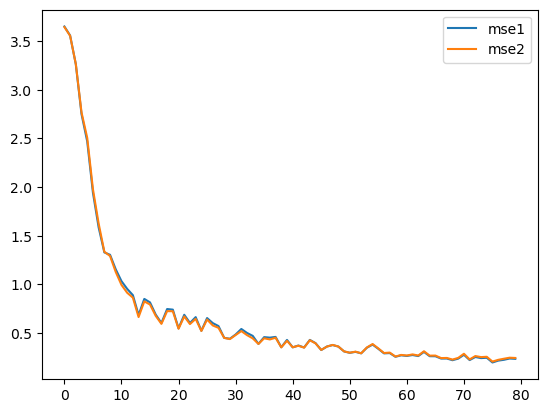

In [221]:
plt.plot(np.array(losses_1['mse'])[::4], label='mse1')
plt.plot(np.array(losses_2['mse'])[::4], label='mse2')
plt.legend()
plt.show()


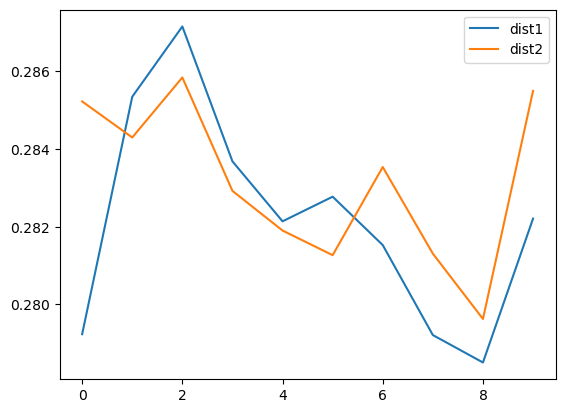

In [223]:
plt.plot(np.array(losses_1['distribution'])[-10:], label='dist1')
plt.plot(np.array(losses_2['distribution'])[-10:], label='dist2')
plt.legend()
plt.show()


In [201]:
import matplotlib.pyplot as plt

In [226]:
log_file = os.path.join(base_dir, "trial0.json")
with open(log_file, "r") as f:
    log_data = json.load(f)




In [229]:
log_data.keys()

dict_keys(['training_config', 'model_config', 'data_config', 'use_distribution_loss', 'use_diffusion_loss', 'mse_only_losses', 'dist_losses'])

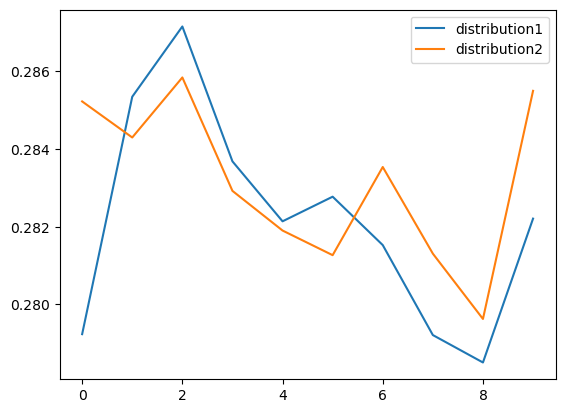

In [231]:
#plt.plot(losses_1['mse'], label='mse1')
plt.plot(log_data['mse_only_losses']['distribution'][-10:], label='distribution1')
#plt.plot(losses_2['mse'], label='mse2')
plt.plot(log_data['dist_losses']['distribution'][-10:], label='distribution2')
plt.legend()
plt.show()

In [98]:
trainer = tru.ClimsimTrainer(model, dataloaders, loss_fn, optimizer, 
                   tconfig, base_dir, use_distribution_loss, use_diffusion_loss, rank=0)

Initializing trainer with rank: 0
Using device: cuda:0


In [108]:
old_stderr = sys.stderr

In [ ]:
with open(os.path.join(trainer.dirs['output_dir'], f"{run_id}.txt"), "w") as f:
    print(f"Redirecting stderr to {f.name}")
    #stderr_fd = sys.stderr.fileno()
    #old_stderr = os.dup(stderr_fd)
    #os.dup2(f.fileno(), stderr_fd)
    sys.stderr = f
    trainer.train(num_epochs=10, log=True, run_id=run_id)


Redirecting stderr to /mnt/home/ssa2206/Climsim/experiments/JointTraining/outputs/trial0_just_mse.txt
Getting ready to train model for 10 epochs
Epoch 1/10
__________
Currently at epoch 0, step 0/64
Currently at epoch 0, step 10/64
Currently at epoch 0, step 20/64
Currently at epoch 0, step 30/64
Currently at epoch 0, step 40/64
epoch 0, step 49: saving checkpoint


## Baselines: Distribution Loss

In [3]:
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
use_distribution_loss = True
use_diffusion_loss = False

In [4]:
exp_dir= "/mnt/home/ssa2206/Climsim/experiments"
exp_id = "JointTraining"
run_id = "testing_dist_loss"
base_dir = os.path.join(exp_dir, exp_id)
tconfigs, mconfigs, dconfig = setup_run(4, exp_id, run_id, 'v1', 128)
dconfig.train_test_split = [0.01, 0.005]


In [5]:
dataloaders, indices = data.load_dataloaders(dconfig, log=True)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [7]:
dl, edl = dataloaders
print(len(dl.dataset))
batch = dl.dataset[14]

16


{"event": "get-batch start", "time": 1744065832.57132, "pid": 2432107, "batch_idx": 14}
{"event": "get-batch end", "time": 1744065837.9901967, "pid": 2432107, "batch_idx": 14, "duration": 5.418865203857422}


In [8]:
x, y = batch[0].to(device), batch[1].to(device)
x.shape, y.shape, x.device, y.device

(torch.Size([49152, 124]),
 torch.Size([49152, 128]),
 device(type='cuda', index=0),
 device(type='cuda', index=0))

In [12]:
ckpt_path = os.path.join(base_dir, "checkpoints", "trial0_dist_loss.pt")
model = tru.build_baseline_model(mconfigs[0], from_ckpt=True, ckpt_path=ckpt_path).to(device)

/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/models.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(kwargs["ck

In [271]:
permute_indices = data.image_regridding(dl.dataset.dsi)
ximg = x.reshape(-1, 384, 124)[:, permute_indices, :]
yming = y.reshape(-1, 384, 128)[:, permute_indices, :]
ximg = ximg.reshape(-1, 16, 24, 124).detach().cpu().numpy()
yimg = y.reshape(-1, 16, 24, 128).detach().cpu().numpy()

In [16]:
y_hat = model(x)
y_hat.shape, y_hat.device

(torch.Size([49152, 128]), device(type='cuda', index=0))

In [13]:
#m = tru.build_baseline_model(mconfigs[0]).to(device)
loss_fn = torch.nn.MSELoss()


In [14]:
def get_loss_gradients(loss_fn, y, y_hat):
    loss = loss_fn(y_hat, y)
    loss.backward(retain_graph=True)
    gradients = {}
    for name, param in model.named_parameters():
        #  print(name, param.shape, param.grad.shape)
        gradients[name] = param.grad.detach().cpu().numpy()
    return(gradients)


## Defining Dist Loss

### Selecting Var

In [15]:
mlo = dl.dataset.mlo

In [61]:
def eval_density(GMM, x, training=True, return_components=False):
    x = x[:, None]
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x,)

In [62]:
def hist(data, title, **kwargs):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    plt.hist(data, **kwargs)
    if('label' in kwargs):
        plt.legend()
    plt.title(title)

def plot_gmm_distribution(gmm, data, n_points=1000, components=False):
    if(isinstance(data, torch.Tensor)):
        data = data.detach().cpu().numpy()
    # Create a range of x values to evaluate the GMM on
    x = torch.linspace(data.min(), data.max(), n_points)
    ret = eval_density(gmm, x, training=False, return_components=components)
    # Plot histogram of actual data
    plt.hist(data, bins=50, density=True, alpha=0.5, label='Data')
    
    # Plot GMM density
    plt.plot(x, ret[0], 'r-', lw=2, label='GMM')
    if(components):
        plt.plot(x, ret[1][:,0], 'b-', lw=2, label='Component 1')
        plt.plot(x, ret[1][:,1], 'g-', lw=2, label='Component 2')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()
    return(ret[0])

In [71]:
from ipywidgets import interact, widgets
from matplotlib import pyplot as plt
def variable_dist_viewer(y, cmap='viridis', dataset=dataloaders[0].dataset):
    y = y.detach().cpu().numpy()
    # Define interactive plot function
    def plot_image(variable):
        hist(y[:, variable], title=f"Variable {dataset.mlo[variable].item()} from y_test")

        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = y.shape
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    
    # Display interactive plot
    interact(plot_image, variable=variable_slider)

# Example usage:
# images = np.random.rand(100, 128, 16, 24) # Replace with your actual data
variable_dist_viewer(y)

interactive(children=(IntSlider(value=0, description='Variable:', max=127), Output()), _dom_classes=('widget-i…

In [88]:

from ipywidgets import interact, widgets
from matplotlib import pyplot as plt
def discrepancy_viewer(y, cmap='viridis'):
    # Define interactive plot function
    gmm = GaussianMixture(n_components=3)
    def plot_image(variable):
        y_sel = y[:, variable].detach().cpu().numpy()
        y_hat_sel = y_hat[:, variable].detach().cpu().numpy()
        gmm.fit(y_sel.reshape(-1,1))
        x = torch.linspace(y_hat_sel.min(), y_hat_sel.max(), 1000)
        densities = torch.exp(torch.tensor(gmm.score_samples(x.reshape(-1,1))))
        plt.plot(x, densities, label='gmm density learned from y')
        plt.hist(y_hat_sel, density=True, label='histogram of y_hat', bins=50, alpha=0.5)
        plt.hist(y_sel, density=True, label='histogram of y', bins=50, alpha=0.5)
        plt.title(f"Variable {mlo[variable].item()}")
        plt.legend()
        plt.axis("off")
        plt.show()

    # Create interactive widgets
    n, d = y.shape
    variable_slider = widgets.IntSlider(value=0, min=0, max=d-1, step=1, description='Variable:')
    
    # Display interactive plot
    interact(plot_image, variable=variable_slider)

# Example usage:
# images = np.random.rand(100, 128, 16, 24) # Replace with your actual data
discrepancy_viewer(y)

interactive(children=(IntSlider(value=0, description='Variable:', max=127), Output()), _dom_classes=('widget-i…

In [89]:
VAR_IND = 68

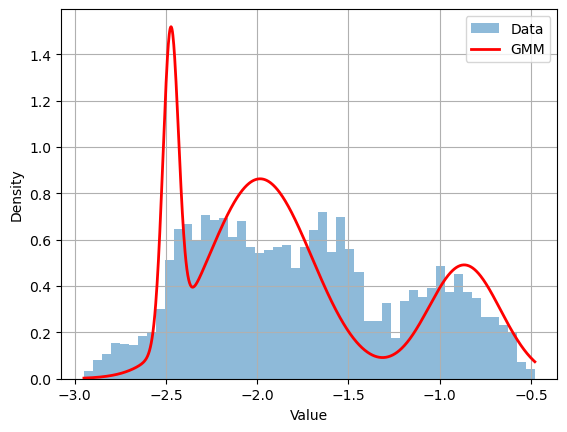

In [90]:
gmm = GaussianMixture(n_components=3)
gmm.fit(y[:,VAR_IND].cpu().numpy().reshape(-1,1))
densities = plot_gmm_distribution(gmm, y_hat[:,VAR_IND].detach().cpu().numpy(), components=False)

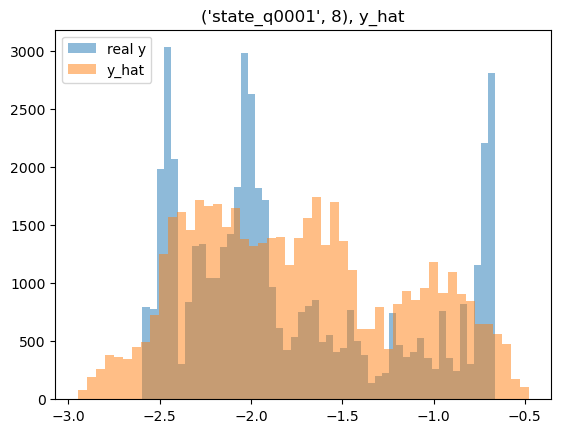

In [91]:
hist(y[:,VAR_IND], title=f'{mlo[VAR_IND].item()}, real y', bins=50, alpha=0.5, label='real y')
hist(y_hat[:,VAR_IND], title=f'{mlo[VAR_IND].item()}, y_hat', bins=50, alpha=0.5, label='y_hat')

Based on the above analyis, we select variable 68, Specific Humidity to target with distribution loss

In [93]:
VAR_IND, mlo[VAR_IND].item()

(68, ('state_q0001', 8))

In [96]:
model, y.shape, y_hat.shape, y.device, y_hat.device, y_hat.requires_grad

(Sequential(
   (0): Linear(in_features=124, out_features=256, bias=True)
   (1): ReLU()
   (2): Linear(in_features=256, out_features=256, bias=True)
   (3): ReLU()
   (4): Linear(in_features=256, out_features=256, bias=True)
   (5): ReLU()
   (6): Linear(in_features=256, out_features=128, bias=True)
 ),
 torch.Size([49152, 128]),
 torch.Size([49152, 128]),
 device(type='cuda', index=0),
 device(type='cuda', index=0),
 True)

### Defining Distribution Loss

In [38]:
def eval_density(GMM, x, training=True, return_components=False):
    x = x[:, None]
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=x.device, requires_grad=training)[None,:] 
    log_probs = -0.5 * torch.log(2 * torch.pi * var) - (x - mu)**2 / (2 * var) 
    probs = torch.exp(log_probs)  # (N, K)
    weighted_probs = pi * probs
    q_x = weighted_probs.sum(dim=1, keepdim=True)  # (N, 1)
    if(return_components):
        return(q_x, weighted_probs)
    return(q_x)

def NLL(GMM, x):
    densities = eval_density(GMM, x)
    return(-torch.mean(torch.log(densities)))

def NLL_loss(y, yhat, var_ind=59, nc=2):
    y_sel = y[:, [var_ind]]
    gmm = GaussianMixture(n_components=nc)
    gmm.fit(y_sel.cpu().numpy())

    return(NLL(gmm, yhat[:, [var_ind]]))


NLL_loss(y, y_hat)

tensor(11.2448, device='cuda:0', dtype=torch.float64, grad_fn=<NegBackward0>)

In [39]:
def score_function(x, mu, var, pi):
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - (x[:,None] - mu) ** 2 / (2 * var)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True))
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * (x[:,None] - mu) / var  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()


def u_q(x_1, x_2, GMM, h=1, debug=False):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x_1.device)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x_1.device)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (technically (n_c, d,d) but flattened), 

    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
    kernel_matrix = torch.exp(- (diffs ** 2) / (2 * h ** 2))
    if debug:
        term_1 = torch.outer(sq1, sq2) * kernel_matrix
        term_2 = sq1.reshape(-1,1) * diffs * kernel_matrix / h**2
        term_3 = -1 * sq2.reshape(1, -1) * diffs * kernel_matrix / h**2    
        term_4 =  (h**-2 - h**-4 * diffs ** 2) * kernel_matrix
        return term_1, term_2, term_3, term_4, kernel_matrix
    
    return(( torch.outer(sq1, sq2) + 
            (sq1.reshape(-1,1) * diffs - sq2.reshape(1, -1) * diffs)/h**2 + 
            (h**-2 - h**-4 * diffs ** 2)) * kernel_matrix)

In [65]:
bs = 6144
VAR_IND = 68
def get_i(x, i):
    return(x[i*bs : (i+1)*bs, VAR_IND])

def distribution_loss(y_hat, y, K=2, VAR_IND=68, n_samples=4, h=1, bs=3072):
    # Fit Gaussian Mixture Model (GMM) to the training data
    gmm = GaussianMixture(n_components=K)
    gmm.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1, 1))

    with torch.no_grad():
        h = 3 * torch.std(y).item()

    ix, jx = torch.randint(0, y_hat.shape[0] // bs, (n_samples,)), torch.randint(0, y_hat.shape[0] // bs, (n_samples,))
    mask = ix == jx
    while mask.any():
        ix[mask] = torch.randint(0, y_hat.shape[0] // bs, (mask.sum(),))
        jx[mask] = torch.randint(0, y_hat.shape[0] // bs, (mask.sum(),))
        mask = ix == jx
    loss = 0
    for i,j in zip(ix, jx):
        y1 = get_i(y_hat, i)
        y2 = get_i(y_hat, j)
        loss += u_q(y1, y2, gmm, h, debug=False).mean()
    return(loss / n_samples)

In [71]:
type( torch.max(var).item() )

float

In [66]:
gmm = GaussianMixture(n_components=2)
gmm.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1, 1))

GaussianMixture(n_components=2)

In [67]:
distribution_loss(y_hat, y)

tensor(0.0008, device='cuda:0', dtype=torch.float64, grad_fn=<DivBackward0>)

### KSD Implementation

Inputs: $y$ and $\hat{y}$, tensors of size $(bs,)$

Output: Loss scalar

1. Train Gaussian Mixture Model to create knowledge distribution $q$. Predictions $\hat{y}$ from model assumed $\sim p$ from which we have $N:= bs // 384$ samples
2. Define $u_q$ function that takes in 2 samples from $p, (\hat{y})$ and returns kernel discrepancy function $$u_q(x, x') := s_q(x) k(x, x') s_q(x') + s_q(x) \nabla_{x'} k(x, x') + s_q(x')  \nabla_{x} k(x,x') +  \nabla_{x,x'} k(x,x')$$

Here we use a Gaussian kernel, so $k(x,x') = \exp(\dfrac{-(x_1-x_2)^2}{2h})$
Since our knowledge distribution $q$ is a Gaussian mixture model, our score function $$s_q(x) = - \sum_{k=1}^K \dfrac{\pi_k \mathcal{N}(x|\mu_k, \sigma_k^2)}{q(x)} \cdot \dfrac{x-\mu_k}{\sigma_k^2} = - \dfrac{\sum_{k=1}^K \pi_k \exp(\dfrac{-(x-\mu_k)^2}{2 \sigma_k^2}) \cdot \dfrac{x-\mu_k}{\sigma_k^2}  }{\sum_{k=1}^K \pi_k \exp(\dfrac{-(x-\mu_k)^2}{2 \sigma_k^2})}$$

3. $U_q := \dfrac{1}{n(n-1)} \sum_{i,j} u_q(x_i, x_j)$

4. Since calculations are all done in Pytorch, can compute $D(\hat{y}) := \dfrac{\partial U_p(\hat{y}_{1:n})}{\partial \hat{y}_i}$

#### Creating function step by step

In [272]:
def plot(x):
    if(isinstance(x, torch.Tensor)):
        x = x.detach().cpu().numpy()
    plt.plot(x)
    plt.show()


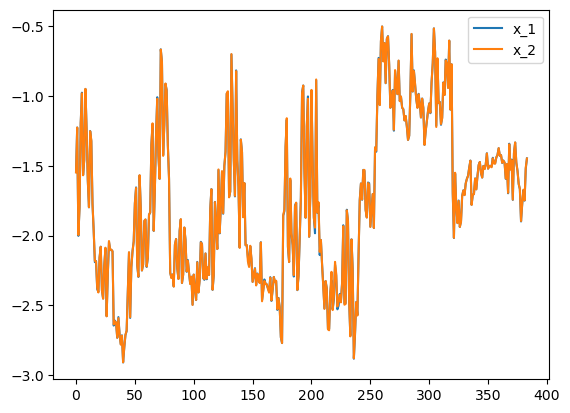

In [19]:
def get_i(x, i, bs=384, var_ind=68):
    return(x[i*bs:(i+1)*bs, var_ind])
x_1 = get_i(y_hat, 0)
x_2 = get_i(y_hat, 1)
x_1.shape, x_2.shape, x_1.device

plt.plot(x_1.detach().cpu().numpy(), label='x_1')
plt.plot(x_2.detach().cpu().numpy(), label='x_2')
plt.legend()
plt.show()


In [21]:
VAR_IND = 68
GMM = GaussianMixture(n_components=3)
GMM.fit(y[:,VAR_IND].detach().cpu().numpy().reshape(-1,1))

GaussianMixture(n_components=3)

In [41]:
y.shape[0] // 384

128

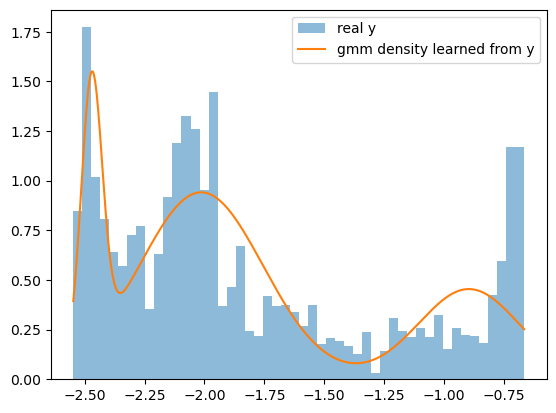

In [ ]:
x = torch.linspace(y[:,VAR_IND].min(), y[:,VAR_IND].max(), 1000)
densities = eval_density(GMM, x, training=False)
plt.hist(y[:,VAR_IND].detach().cpu().numpy(), bins=50, density=True, alpha=0.5, label='real y')
plt.plot(x, densities, label='gmm density learned from y')
plt.legend()
plt.show()


In [28]:
mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (nc, d=1 flattened)
pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,)
var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (technically (n_c, d,d) but flattened), 


mu.shape, pi.shape, var.shape


(torch.Size([1, 3]), torch.Size([1, 3]), torch.Size([1, 3]))

Broadcasting trick: 

By making $x_1$ size (N,1) and $\mu$ (1, K), we allow addition and subtraction operations that create (N,K) size tensors where $M_{ik} = x_i - \mu_k$


In [29]:
x_1.shape
comp_wise = x_1[:,None] - mu
comp_wise[26, 2].item(), (x_1[26] - mu[0,2]).item()

(-0.10810972447950462, -0.10810972447950462)

In [30]:
epsilon = 1e-9 
pi = torch.clamp(pi, min=epsilon)
var = torch.clamp(var, min=epsilon)
mu, pi, var



(tensor([[-2.0135, -0.8966, -2.4701]], device='cuda:0', dtype=torch.float64),
 tensor([[0.6104, 0.2421, 0.1475]], device='cuda:0', dtype=torch.float64),
 tensor([[0.0669, 0.0452, 0.0019]], device='cuda:0', dtype=torch.float64))

$$q(x) = \sum_{k=1}^K \dfrac{\pi_k}{\sigma_k \sqrt{2\pi}} \exp(-\dfrac{(x-\mu_k)^2}{2\sigma^2}) $$

$$s_q(x) = - \sum_{k=1}^K \dfrac{\pi_k \mathcal{N}(x|\mu_k, \sigma_k^2)}{q(x)} \cdot \dfrac{x-\mu_k}{\sigma_k^2}$$

In [31]:
def score_function(x, mu, var, pi):
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - (x[:,None] - mu) ** 2 / (2 * var)
    log_qx = torch.logsumexp(log_probs, dim=1, keepdim=True)
    qx = torch.exp(log_qx)
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * (x[:,None] - mu) / var  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()

In [32]:
log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - (x_1[:,None] - mu) ** 2 / (2 * var)
log_qx = torch.logsumexp(log_probs, dim=1, keepdim=True)
qx = torch.exp(log_qx)
(qx - eval_density(GMM, x_1)).abs().sum()

tensor(1.8867e-14, device='cuda:0', dtype=torch.float64,
       grad_fn=<SumBackward0>)

torch.Size([384]) torch.Size([384])


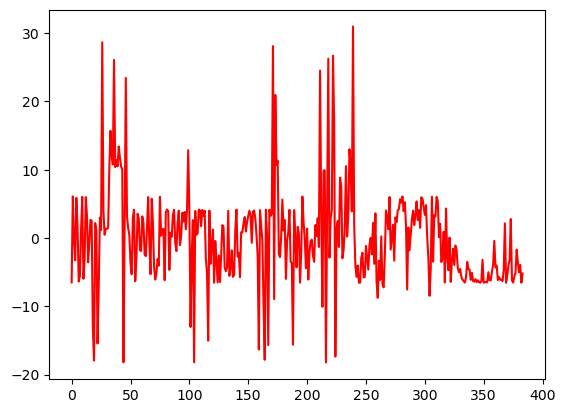

In [33]:
score_function(x_1, mu, var, pi).shape, score_function(x_2, mu, var, pi).shape
sq1 = score_function(x_1, mu, var, pi)
sq2 = score_function(x_2, mu, var, pi)
print(sq1.shape, sq2.shape)
plt.plot(sq1.detach().cpu().numpy(), label='sq1', color='red')

#### Vectorizing Implementation

$\cdot$ denotes matrix mult, $\times$ denotes element wise mult 

Goal: Matrix $M_{ij} := u_q(x_i, x'_j)$

Term 1: $s_q(x) k(x, x') s_q(x')$ - accomplished by $(s_q(x) \cdot s_q(x')^T) \times K$, i.e. $(N,1) \cdot (1,N) \times (N,N) $

Term 2: $s_q(x) \nabla_{x'} k(x, x')$ - make sq1 a column vector, broadcast N times to NxN with N identical columns. Row i is $s_q(x_i)$. Element wise multiplication with $\nabla K$ 

In [34]:
h = 2

h**2, h**-2

(4, 0.25)

In [305]:
diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
kernel_matrix = torch.exp(- (diffs ** 2) / (2 * h ** 2))
# ∇_{x1} k(x1, x2) = - (x1 - x2) * K / h^2
grad_x1 = -diffs * kernel_matrix / h**2               # (N, N)

# ∇_{x2} k(x1, x2) = (x1 - x2) * K / h^2
grad_x2 = diffs * kernel_matrix / h**2                  # (N, N)

# ∇_{x1,x2} k(x1, x2) = (1/h^2 - (x1 - x2)^2 / h^4) * K
grad_x1x2 = (h**-2 - h**-4 * diffs ** 2) * kernel_matrix

kernel_matrix.shape, grad_x1.shape, grad_x2.shape, grad_x1x2.shape

(torch.Size([384, 384]),
 torch.Size([384, 384]),
 torch.Size([384, 384]),
 torch.Size([384, 384]))

In [306]:
i,j = 89, 65

kernel_matrix[i,j].item(), torch.exp(-1*((x_1[i] - x_2[j]) ** 2) / (2 * h ** 2)).item()

(0.8895377516746521, 0.8895377516746521)

In [309]:
grad_x1x2[i,j].item(), ((h**-2 - h**-4 * (x_1[i] - x_2[j]) ** 2) * kernel_matrix[i,j]).item()

(0.1703227460384369, 0.1703227460384369)

In [315]:
term_2 = sq1.reshape(-1,1) * grad_x2
term_2.shape


term_2[92, 4].item(), (sq1[92] * grad_x2[92,4]).item()

(-0.39490377232184454, -0.39490377232184454)

In [316]:
term_3 = sq2.reshape(1, -1) * grad_x1

term_3[86, 268].item(), (sq2[268] * grad_x1[86,268]).item()

(-0.6187573939062931, -0.6187573939062931)

In [35]:
def score_function(x, mu, var, pi):
    log_probs = torch.log(pi) - 0.5 * torch.log(var * 2 * torch.pi) - (x[:,None] - mu) ** 2 / (2 * var)
    qx = torch.exp(torch.logsumexp(log_probs, dim=1, keepdim=True))
        # Compute weighted derivative terms: pi * N(x|mu, var) * (x - mu) / var
    weighted_terms = torch.exp(log_probs) * (x[:,None] - mu) / var  # (N, K)
    # Sum over components and divide by q(x)
    score = -weighted_terms.sum(dim=1, keepdim=True) / qx    # (N, 1)
    return score.squeeze()


def u_q(x_1, x_2, GMM, h=1, debug=False):
    assert len(x_1.shape) == 1 and len(x_2.shape) == 1, "expected 1d input"
    # x_1 and x_2 are samples from q(x), compared to knowledge distribution p(x) represented by mixture model. Thus, they are of shape (n_samples, d)
    mu = torch.tensor(GMM.means_.flatten(), dtype=torch.float64, device=x_1.device)[None,:] # (n_components,) (nc, d=1 flattened)
    pi = torch.tensor(GMM.weights_.flatten(), dtype=torch.float64, device=x_1.device)[None,:] # (n_components,)
    var = torch.tensor(GMM.covariances_.flatten(), dtype=torch.float64, device=device)[None,:] # (n_components,) (technically (n_c, d,d) but flattened), 

    # Ensure pi and var are positive and non-zero for stability
    epsilon = 1e-9 
    pi = torch.clamp(pi, min=epsilon)
    var = torch.clamp(var, min=epsilon)

    sq1 = score_function(x_1, mu, var, pi)
    sq2 = score_function(x_2, mu, var, pi)

    # Compute the final result based on bandwidth h
    if h == float('inf'):
        return torch.outer(sq1, sq2)
    else:
        diffs = x_1.unsqueeze(1) - x_2.unsqueeze(0)
        kernel_matrix = torch.exp(- (diffs ** 2) / (2 * h ** 2))
        term_1 = torch.outer(sq1, sq2) * kernel_matrix
        term_2 = sq1.reshape(-1,1) * diffs * kernel_matrix / h**2
        term_3 = -1 * sq2.reshape(1, -1) * diffs * kernel_matrix / h**2    
        term_4 =  (h**-2 - h**-4 * diffs ** 2) * kernel_matrix
        if debug:
            return term_1, term_2, term_3, term_4, kernel_matrix
        return (term_1 + term_2 + term_3 + term_4)

In [37]:
%%time
uq = u_q(y_hat[:,VAR_IND], y_hat[:,VAR_IND], GMM)

OutOfMemoryError: CUDA out of memory. Tried to allocate 18.00 GiB. GPU 0 has a total capacity of 79.20 GiB of which 6.22 GiB is free. Including non-PyTorch memory, this process has 72.98 GiB memory in use. Of the allocated memory 72.28 GiB is allocated by PyTorch, and 40.08 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [340]:
uq = u_q(get_i(y_hat, 0), get_i(y_hat, 0), gmm, debug=True)

Verified couple sanity check maneuvers: 

1. Shuffling the tensors (torch.randperm) before passing in does nothing to the mean because $M_{ij}$ really seems to work as expected

In [350]:
def shuf(x):
    return x[torch.randperm(x.shape[0])]

In [358]:
x1 = get_i(y_hat, 10)
x2 = get_i(y_hat, 100)

rand_ind = torch.randperm(x1.shape[0]).detach().cpu().numpy().tolist()
rand_ind_2 = torch.randperm(x2.shape[0]).detach().cpu().numpy().tolist()
x1_shuf = x1[rand_ind]
x2_shuf = x2[rand_ind_2]

uq = u_q(x1, x2, gmm, debug=True)
uq_shuf = u_q(x1_shuf, x2_shuf, gmm, debug=True)

In [360]:

for u, ushuf in zip(uq, uq_shuf):
    print(u.mean().item(), ushuf.mean().item())
    print(u[10, 10].item(), ushuf[10, 10].item())
    print(u[rand_ind[10], rand_ind_2[10]].item(), ushuf[10, 10].item(), "\n\n")


0.5693951214589904 0.5693951214589904
22.549721939393862 -14.608337746929598
-14.608337746929598 -14.608337746929598 


-0.5013591543846695 -0.5013591543846694
-0.3081635279366634 -1.9710202969963195
-1.9710202969963195 -1.9710202969963195 


-0.4253574075626402 -0.42535740756264023
0.44885806008295076 -3.0603847898246723
-3.0603847898246723 -3.0603847898246723 


0.44678905606269836 0.4467889964580536
0.9907941222190857 0.3499825596809387
0.3499825596809387 0.3499825596809387 


0.7694668173789978 0.769466757774353
0.9969282150268555 0.7629029750823975
0.7629029750823975 0.7629029750823975 




In [44]:
6144 // 384

16

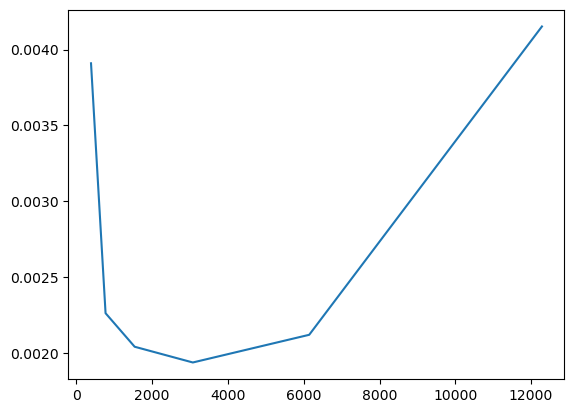

In [43]:
import time
times = []
sizes = [384, 768, 1536, 3072, 6144, 12288]
for bs in sizes:
    t0 = time.time()
    uq = u_q(get_i(y_hat, 0, bs=bs), get_i(y_hat, 1, bs=bs), GMM, debug=True)
    times.append(time.time() - t0)
plt.plot(sizes, times)
plt.show()


In [ ]:
mse_gradients = get_loss_gradients(loss_fn, y, y_hat)

In [333]:
for name in names:
    print(f"mse : {mse_gradients[name].mean()}, nll : {nll_gradients[name].mean()}")

mse : -0.00030138809233903885, nll : -0.0004271512443665415
mse : 0.00033526954939588904, nll : 0.000518108019605279
mse : 2.3643107851967216e-05, nll : -0.0002450272149872035
mse : 9.314161434303969e-05, nll : -0.00033362951944582164
mse : -3.025284968316555e-05, nll : -0.000310779083520174
mse : -0.00012433109804987907, nll : -0.0013460299232974648
mse : 0.0004090542788617313, nll : -0.0006081417668610811
mse : -0.0013874778524041176, nll : -0.016633838415145874


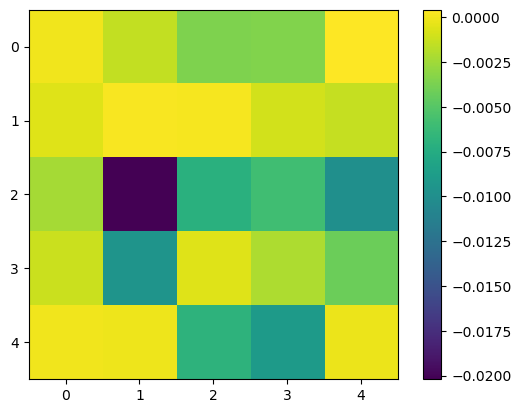

In [337]:
plt.imshow(mse_gradients[names[2]][40:45, 10:15])
plt.colorbar()
plt.show()



In [29]:
n_samples = 10
bs = y.shape[0] // 384
ix, jx = torch.randint(0, bs, (n_samples,)), torch.randint(0, bs, (n_samples,))
mask = ix == jx
while mask.any():
    ix[mask] = torch.randint(0, bs, (mask.sum(),))
    jx[mask] = torch.randint(0, bs, (mask.sum(),))
    mask = ix == jx
ix, jx

(tensor([  4,  70,  76,  39,  73, 126,  75,  83,  30,  80]),
 tensor([ 63,  21,   8,  52,  72,  92,  88, 124,  83,  19]))

## Training on Dist Loss

In [80]:
model = tru.build_baseline_model(mconfig, from_ckpt=False)#, ckpt_path=base_dir + '/testing_just_mse-ckpt.pt')

/tmp/ipykernel_112540/1088601492.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(kwargs["ckpt_path"], map_location=torch.device('cpu'))

In [82]:
def evaluate(model):
    model.eval()
    with torch.no_grad():
        total_loss = loss_fn(model(test_ds.X), test_ds.Y)
        return(total_loss / test_ds.Y.shape[0])

## Scratch

In [ ]:
n_samples = 3

ix, jx = torch.randint(0, bs, (n_samples,)), torch.randint(0, bs, (n_samples,))
mask = ix == jx
while mask.any():
    ix[mask] = torch.randint(0, bs, (mask.sum(),))
    jx[mask] = torch.randint(0, bs, (mask.sum(),))
    mask = ix == jx

ix, jx

In [63]:
model, losses = vanilla_train(model, train_ds, loss_fn, tconfig)

Epoch [1/10], Train Loss: 0.0505, Test Loss: 0.0336
Epoch [2/10], Train Loss: 0.0204, Test Loss: 0.0393
Epoch [3/10], Train Loss: 0.0180, Test Loss: 0.0469
Epoch [4/10], Train Loss: 0.0170, Test Loss: 0.0483
Epoch [5/10], Train Loss: 0.0164, Test Loss: 0.0500
Saving Model
Epoch [6/10], Train Loss: 0.0160, Test Loss: 0.0531
Epoch [7/10], Train Loss: 0.0158, Test Loss: 0.0555
Epoch [8/10], Train Loss: 0.0155, Test Loss: 0.0577
Epoch [9/10], Train Loss: 0.0154, Test Loss: 0.0591
Epoch [10/10], Train Loss: 0.0152, Test Loss: 0.0607
Saving Model


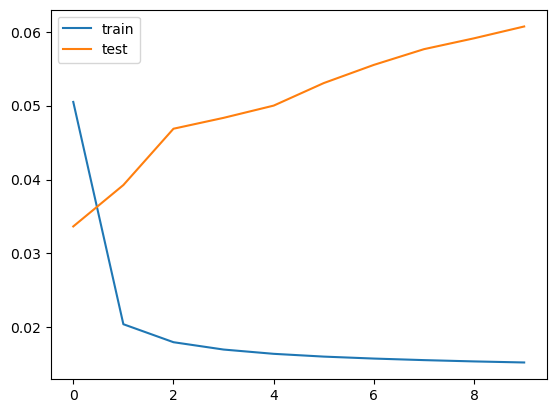

In [64]:
plt.plot(losses['train'], label='train')
plt.plot(losses['test'], label='test')
plt.legend()
plt.show()

## Diffusion Augmented training

In [33]:
exp_id = "full_dataset_testrun"
base_dir = os.path.join("experiments", exp_id)
run_id = "trial_1b"
tconfig, mconfig, dconfig = tru.load_config(run_id, exp_id)


TrainLoaderParams(batch_size=256, shuffle=True, num_workers=8, prefetch_factor=4, persistent_workers=True, multiprocessing_context='forkserver', pin_memory=True)

In [7]:
ddpm = tru.load_model_from_ckpt(f"{run_id}-ckpt.pt", mconfig, exp_id).to(device)
mconfig.scheduler_type = "ddim"
scheduler = data.load_scheduler(mconfig)
scheduler.set_timesteps(num_inference_steps=mconfig.scheduler_inference_steps)
ddpm.device

device(type='cuda', index=0)

In [8]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [49]:
%%time
x, y = train_ds[0]

CPU times: user 505 ms, sys: 775 ms, total: 1.28 s
Wall time: 1.18 s


In [52]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [14]:
y_hat = model(x.to(device))

In [15]:
def construct_image(ytensor):
    # more complex in actual setup
    return(torch.transpose(ytensor, 1, 2).reshape(-1, 128, 16, 24))

In [103]:
loss_fn = nn.MSELoss()
def image_loss(y, yhat, T: int, unet=ddpm, scheduler=scheduler):
    y, yhat = construct_image(y), construct_image(yhat)
    def encode(sample):
        eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([T])) # noisy image
        return(xt)
    def decode(xt):
        for t in range(T, 0, -1):
            with torch.no_grad():
                eps_theta = unet(xt, t).sample
            xt = scheduler.step(eps_theta, t, xt).prev_sample
        return(xt)
    yhat = decode(encode(yhat))
    return(loss_fn(y, yhat))

In [54]:
image_loss(y.to(device), y_hat, 25)

tensor(1.4329, device='cuda:0', grad_fn=<MseLossBackward0>)

In [62]:
4204/256

16.421875

In [69]:
tconfig.num_epochs

20

In [72]:

len(test_ds)

8

In [80]:
%%time
c, d = train_ds[5]

CPU times: user 437 ms, sys: 1.85 ms, total: 438 ms
Wall time: 402 ms


In [81]:
%%time
loss_fn(model(a.to(device)), b.to(device))

CPU times: user 29.9 ms, sys: 0 ns, total: 29.9 ms
Wall time: 29.5 ms


tensor(0.9858, device='cuda:0', grad_fn=<MseLossBackward0>)

In [76]:
def evaluate_diff(model):
    loss = 0.0
    model.eval()
    with torch.no_grad():
        for idx in range(len(test_ds)):
            print(idx, end=" ")
            x, y = test_ds[idx]
            x, y = x.to(device), y.to(device)
            loss += loss_fn(model(x), y).item()
    return(loss / len(test_ds))

In [107]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [121]:
def diffusion_train(model, dataset, loss_fn, tconfig):
    optimizer = torch.optim.Adam(model.parameters(), lr=tconfig.learning_rate, weight_decay=1e-4)
    losses = dict(train=[], diffusion=[], test=[])
    for epoch in range(1, tconfig.num_epochs+1):
        model.train()  # Set the model to training mode
        pixel_loss, img_loss = 0.0, 0.0
        for idx in range(len(dataset)):
            print(idx, end=" ")
            x, y = dataset[idx]
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            ploss = loss_fn(y, y_hat)
            iloss = image_loss(y, y_hat, T=25)
            (ploss + iloss).backward()
            optimizer.step()
            pixel_loss += ploss.item(); img_loss += iloss.item()
            losses['train'].append(ploss.item()); losses['diffusion'].append(iloss.item());
        # Print training progress
        #average_loss = running_loss / len(dataloader)
        #test_loss = evaluate(model).item()
        print(f'\nEpoch [{epoch}/{tconfig.num_epochs}], Pixel Loss: {pixel_loss/len(dataset):.4f}, Image Loss: {img_loss/len(dataset):.4f}')
        
        if(epoch % tconfig.batch_checkpoint_interval == 0):
            print("Saving Model")
            torch.save(model.state_dict(), tconfig.ckpt_id)

    return(model, losses)

In [116]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [122]:
loss_fn(model(x.to(device)), y.to(device))

tensor(1.3941, device='cuda:0', grad_fn=<MseLossBackward0>)

In [123]:
x, y = train_ds[0]

In [127]:
model, losses = diffusion_train(model, train_ds, loss_fn, tconfig)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [1/10], Pixel Loss: 1.0640, Image Loss: 1.0884
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [2/10], Pixel Loss: 1.0268, Image Loss: 1.0556
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [3/10], Pixel Loss: 0.9956, Image Loss: 1.0274
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [4/10], Pixel Loss: 0.9671, Image Loss: 1.0011
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [5/10], Pixel Loss: 0.9403, Image Loss: 0.9758
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [6/10], Pixel Loss: 0.9146, Image Loss: 0.9515
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [7/10], Pixel Loss: 0.8901, Image Loss: 0.9280
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [8/10], Pixel Loss: 0.8668, Image Loss: 0.9055
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [9/10], Pixel Loss: 0.8446, Image Loss: 0.8840
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [10/10], Pixel Loss: 0.8236, Image Loss: 0.8637


In [130]:
torch.save(model.state_dict(), "experiments/JointTraining/diffusion_train.pt")

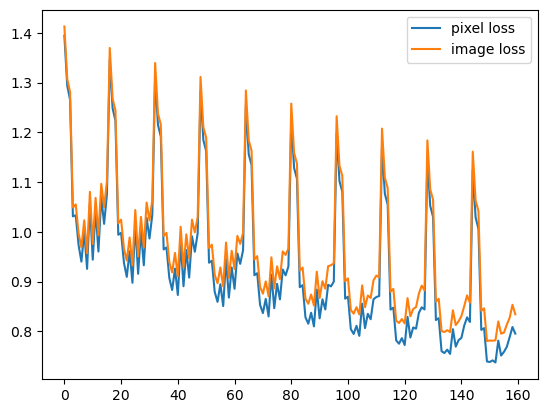

In [134]:
plt.plot(losses['train'], label='pixel loss')
plt.plot(losses['diffusion'], label='image loss')
plt.legend()
plt.show()

In [137]:
import json

In [139]:
with open("experiments/JointTraining/diffusion_train_losses.json", "w") as file:
    json.dump(losses, file)